# Rango de Frecuencias

En este notebook se buscará predecir la variable objetivo realizando el preprocesamiento de los datos agrupando por frecuencias para así reducir la dimensión.

**Ventajas del preprocesamiento:**
* Puede reducir mucho la dimensión, asunto importante a tratar en este dataset, cuyas dimensiones traen problemas para modelos como regresión lineal.
* Es sencillo de realizar y de entender.
*

**Desventajas:**
* No disminuye la cantidad de variables necesarias a medir para realizar la predicción, pues sería necesario sacar muestras de todas las frecuencias utilizadas en el dataset para tomar el promedio... es decir: es igual o más costoso.
* 
*

Los **modelos** propuestos para dicho preprocesamiento de los datos serán:
* Regresión lineal (regularizada según elastic net)
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica


Se utilizará **KFold cross validation** para encontrar los parámetros de los modelos así como la ventana del preprocesamiento.

#### Bibliotecas

In [1]:
library(glmnet)
library(pracma)
library(MASS)
library(ggplot2)
library("partykit")
source("Utils.R")

Loading required package: Matrix

Loaded glmnet 4.1-2


Attaching package: ‘pracma’


The following objects are masked from ‘package:Matrix’:

    expm, lu, tril, triu


Loading required package: grid

Loading required package: libcoin

Loading required package: mvtnorm



In [2]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

StScaler <- import("sklearn.preprocessing", convert = FALSE)$StandardScaler
MMScaler <- import("sklearn.preprocessing", convert = FALSE)$MinMaxScaler

#### Preprocesamiento

In [3]:
# Función que recibe un dataframe ('X') y un tamanio de ventana ('tamanio_ventana', 'tv')
# Devuelve otro dataframe donde cada columna es la media de las vecinas
#  en ventanas del tamanio recibido como segundo parametro.

# Por ejemplo:

# X=                       Y=
# A B C D E F G            Y1  Y2  Y3  Y4
# 1 2 1 2 1 2 1    tv=2    1.5 1.5 1.5 1.0
# 2 2 2 2 2 2 2    --->    2.0 2.0 2.0 2.0
# 3 3 4 4 5 5 1            3.0 4.0 5.0 1.0
# 1 2 3 4 5 6 7            1.5 3.5 5.5 7.0

preprocesamiento_agrupar <- function(X, tamanio_ventana) {
  if(tamanio_ventana==1){
      return(X)
  }
  X_means <- data.frame(matrix(NA, nrow = nrow(X), ncol = ceiling(ncol(X) / tamanio_ventana)))
  last_i <- floor(ncol(X) / tamanio_ventana)
  for (i in 1:last_i) {
    j <- i - 1
    X_means[,i] <- rowMeans(X[, (j * tamanio_ventana + 1): (i * tamanio_ventana)])
  }
  num_last_cols <- i * tamanio_ventana + ncol(X) %% tamanio_ventana
  num_first_last_cols <- last_i * tamanio_ventana + 1
  if(num_first_last_cols > num_last_cols){
      return(X_means)
  } else if(num_first_last_cols != num_last_cols) {
    X_means[,ceiling(ncol(X) / tamanio_ventana)] <- rowMeans(X[, num_first_last_cols: num_last_cols])
  } else {
    X_means[,ceiling(ncol(X) / tamanio_ventana)] <- X[, num_first_last_cols]
  }
  return (X_means)
}

#### Obteniendo los datos

Además dividimos el set en entrenamiento en hold out (para decidir si recomendamos el modelo o no...) 

In [4]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y


hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

# Modelo 1: regresión lineal regularizada

### Busqueda de los parametros de la prediccion.

In [7]:
setSeed()
n = nrow(TRAIN_X)
k = 5
resultados <- data.frame(
  Ventana   =double(), 
  Alpha     =double(),
  Lambda    =double(),
  Escalador =integer(),
  Error     =double()
)

ventanas = seq(2, 30, 1)
indices = obtener_indices_kfold(n, k)
escaladores <- c(StScaler(), MMScaler())

for(ventana in ventanas){
    X <- preprocesamiento_agrupar(TRAIN_X, ventana)
    for(alpha in seq(0, 1, 0.1)){
        for(lambda in logspace(-10, -2, 9)){
            for(s in 1:length(escaladores)){
                escalador = escaladores[[s]]
                err = 0
                for(i in indices){
                    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                    Y_train = TRAIN_Y[-i]

                    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                    Y_test = TRAIN_Y[i]

                    model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
                    Y_pred = predict(model, X_test_scaled)
                    err = err + sum((Y_test - Y_pred)^2)
                }
                resultados = rbind(resultados, list(ventana, alpha, lambda, s, err/n))
            }
        }
    }
    message(progreso(ventana, ventanas))
}
colnames(resultados)  <- c("Ventana", "alpha", "lambda", "Escalador", "Error")

El progreso es del 3.4 %

El progreso es del 6.9 %

El progreso es del 10.3 %

El progreso es del 13.8 %

El progreso es del 17.2 %

El progreso es del 20.7 %

El progreso es del 24.1 %

El progreso es del 27.6 %

El progreso es del 31 %

El progreso es del 34.5 %

El progreso es del 37.9 %

El progreso es del 41.4 %

El progreso es del 44.8 %

El progreso es del 48.3 %

El progreso es del 51.7 %

El progreso es del 55.2 %

El progreso es del 58.6 %

El progreso es del 62.1 %

El progreso es del 65.5 %

El progreso es del 69 %

El progreso es del 72.4 %

El progreso es del 75.9 %

El progreso es del 79.3 %

El progreso es del 82.8 %

El progreso es del 86.2 %

El progreso es del 89.7 %

El progreso es del 93.1 %

El progreso es del 96.6 %

El progreso es del 100 %



Los mejores parámetros obtenidos son:

In [8]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,Ventana,alpha,lambda,Escalador,Error
,<dbl>,<dbl>,<dbl>,<int>,<dbl>
2588,15,0,1e-04,2,0.6302542


Podemos ver que el tamaño de la ventana es 15, por lo tanto tendremos 21 variables, por lo que vemos que se redujo considerablemente la dimensión (entr 14 y 15 veces...).

Otra cosa a notar es que alpha de elastic net dio 0, por lo tanto no se aplicará nada de Lasso sólo Ridge.

#### El modelo
Ŷ = a0 + b1·X1 + b2·X2 + ... + b20·X20 + b21·X21

In [11]:
X <- preprocesamiento_agrupar(TRAIN_X, mejores_parametros$Ventana)
Y <- TRAIN_Y
escalador <- escaladores[[mejores_parametros$Escalador]]
X_scaled <- as.matrix(escalador$fit_transform(X))
modelo1 <- glmnet(X_scaled, Y, alpha=mejores_parametros$alpha, lambda=mejores_parametros$lambda)

Veamos cómo quedaron los betas... de menor a mayor

In [8]:
sort(abs(modelo1$beta[,1]))

V21         V4         V6         V2        V12         V3        V20 
 0.5740894  0.6581247  1.1128386  1.7989857  3.0924575  3.5083489  3.8140442 
       V18         V7        V19        V16        V13        V17        V11 
 5.8906089  6.7636490  7.5507228  8.9309725  9.2766529  9.6335831 10.2146277 
       V15         V8        V14         V1         V5        V10         V9 
11.1307730 12.1272279 15.3464341 16.7564263 17.3381041 26.9405835 37.0407505

Vemos que efectivametne existen betas cuyo valor es significativamente más chico frente a otros, sin embargo aún queda notar si existe relación entre los rangos de frecuencia para los cuales el rango no sea tan significativo. 

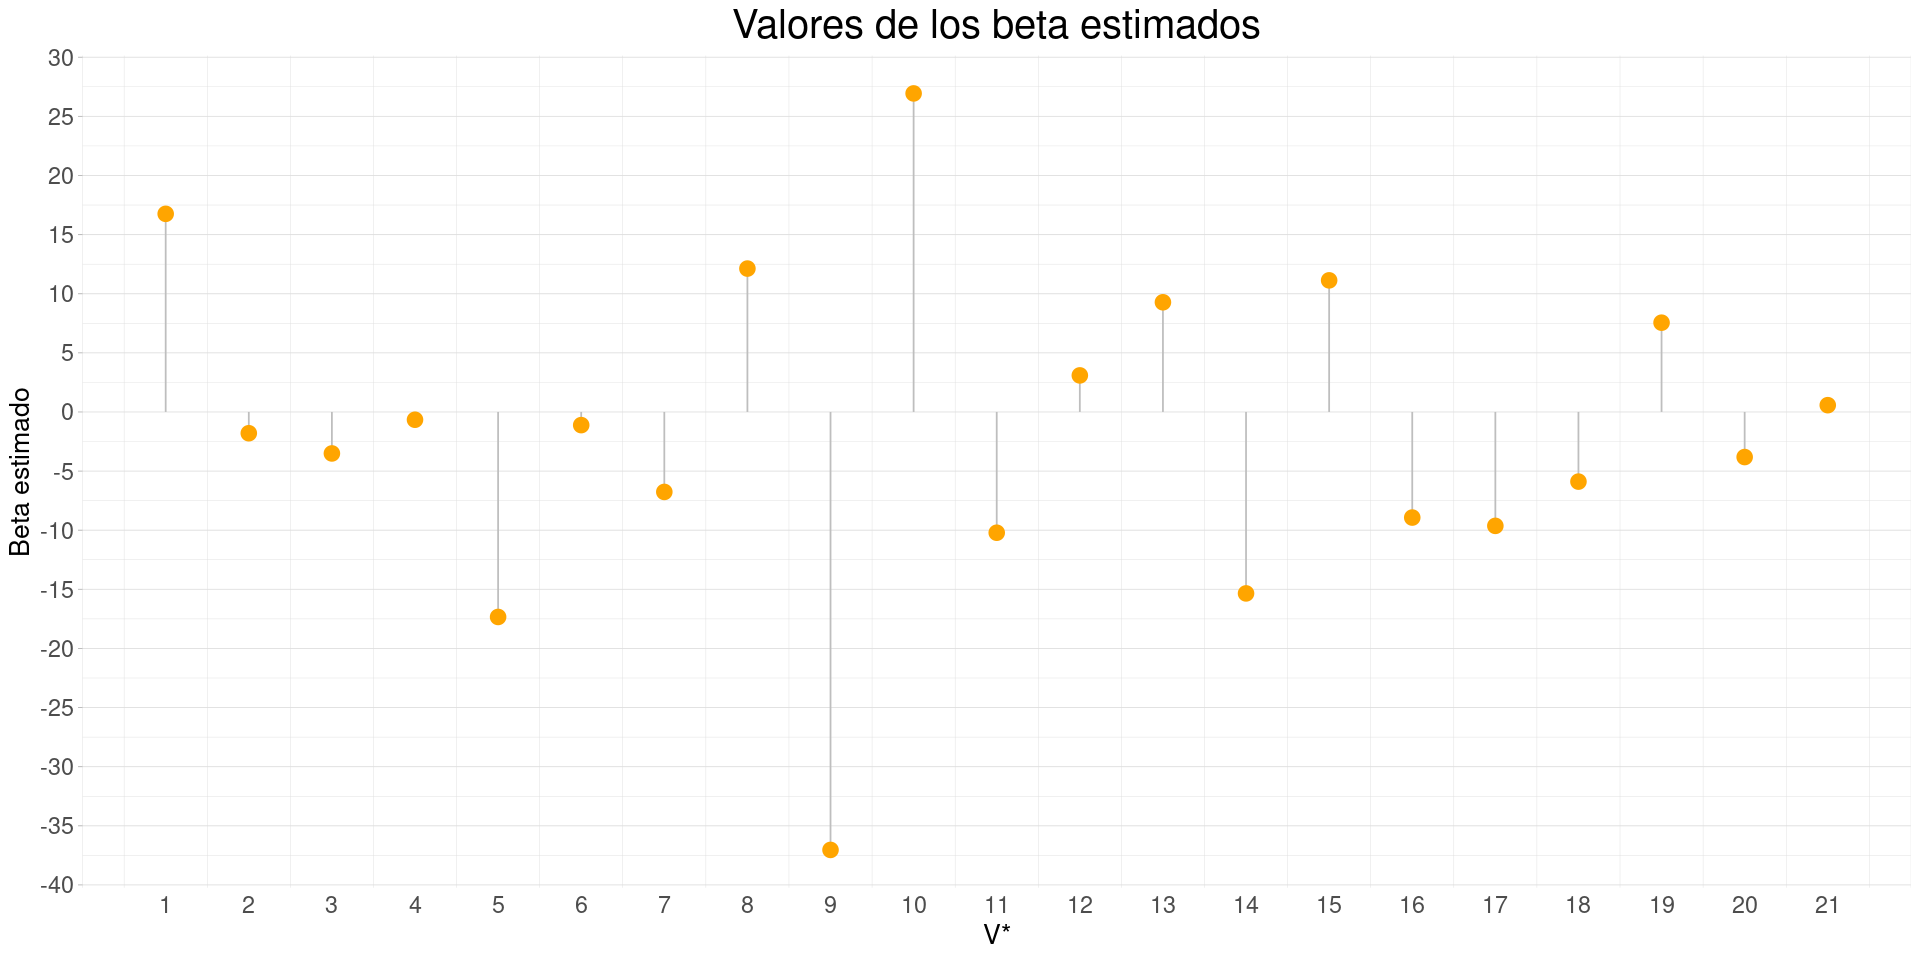

In [13]:
x_plot = as.integer(sub('.', '', colnames(X)))

data_plot <- data.frame(
  x=x_plot,
  y=modelo1$beta[,1]
)


# Plot

options(repr.plot.width=16, repr.plot.height=8)

colores = sapply(modelo1$beta[,1], function(x) (ifelse(x!=0, "orange",  "purple")))
ggplot(data_plot, aes(x=x, y=y)) +
  ggtitle("Valores de los beta estimados") +
  geom_segment( aes(x=x, xend=x, y=0, yend=y), color="grey") +
  geom_point(color=colores, size=4) +
  theme_light() +
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
  scale_x_continuous(breaks = seq(1, 21)) +
  scale_y_continuous(breaks = seq(-40, 30, by=5)) +
  xlab("V*") + ylab("Beta estimado")

#### Cálculo del error
Para ello se realizará leave one out cross validation con los mejores parámetros para obtener un menor sesgo en la estimación del error (que será el que "publicaremos")

In [24]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)

X <- preprocesamiento_agrupar(TRAIN_X, mejores_parametros$Ventana)
escalador <- escaladores[[mejores_parametros$Escalador]]

err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(err)

[1] 0.6782032


Vemos que el error resulta bastante similar al obtenido previamente con Kfold, pero un poco más grande (que tiene sentido al no subestimar su valor)

# Modelo 2: árbol de regresión

In [17]:
library(rpart)
library(rpart.plot)

In [19]:
setSeed()

n = nrow(TRAIN_X)
k = 10

resultados <- data.frame(
  Ventana  =integer(), 
  Minsplit =double(),
  Maxdepth =double(),
  CP       =double(),
  Error    =double()
)
ventanas <- seq(2, 31, 2)

indices = obtener_indices_kfold(n, k)

minsplits <- c(2, 5, 10, 15, 20, 25)
maxdepths <- c(4, 5, 6, 7, 8)
cps <- c(0.0005, 0.001, 0.005, 0.01, 0.015, 0.025)

for(ventana in ventanas){
    X <- preprocesamiento_agrupar(TRAIN_X, ventana)
    for (minsplit in minsplits) {
        for (maxdepth in maxdepths) {
            for (cp in cps) {
                parametros = rpart.control(minsplit=minsplit, maxdepth=maxdepth, cp=cp)
                err = 0
                for(i in indices){
                    DF_train = X[-i,]
                    DF_train$Y = TRAIN_Y[-i]

                    DF_test = X[i,]
                    DF_test$Y = TRAIN_Y[i]

                    model <- rpart(Y ~ ., data = DF_train, control=parametros)
                    Y_pred = predict(model, DF_test)
                    err = err + sum((DF_test$Y - Y_pred)^2)
                }
                resultados = rbind(resultados, list(ventana, minsplit, maxdepth, cp, err/n))
            }
        }
    }
    message(progreso(ventana, ventanas))
}
colnames(resultados)  <- c("Ventana", "Minsplit", "Maxdepth", "CP", "Error")

El progreso es del 6.7 %

El progreso es del 13.3 %

El progreso es del 20 %

El progreso es del 26.7 %

El progreso es del 33.3 %

El progreso es del 40 %

El progreso es del 46.7 %

El progreso es del 53.3 %

El progreso es del 60 %

El progreso es del 66.7 %

El progreso es del 73.3 %

El progreso es del 80 %

El progreso es del 86.7 %

El progreso es del 93.3 %

El progreso es del 100 %



In [21]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,Ventana,Minsplit,Maxdepth,CP,Error
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,2,2,4,0.001,1.045342


In [32]:
parametros <- rpart.control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, cp=mejores_parametros$CP)

DF_train <- preprocesamiento_agrupar(TRAIN_X, mejores_parametros$Ventana)
colnames(DF_train) <- paste("V*", as.character(1:151), sep="")
DF_train$Y <- TRAIN_Y

modelo2 <- rpart(Y ~ ., data = DF_train, control=parametros)

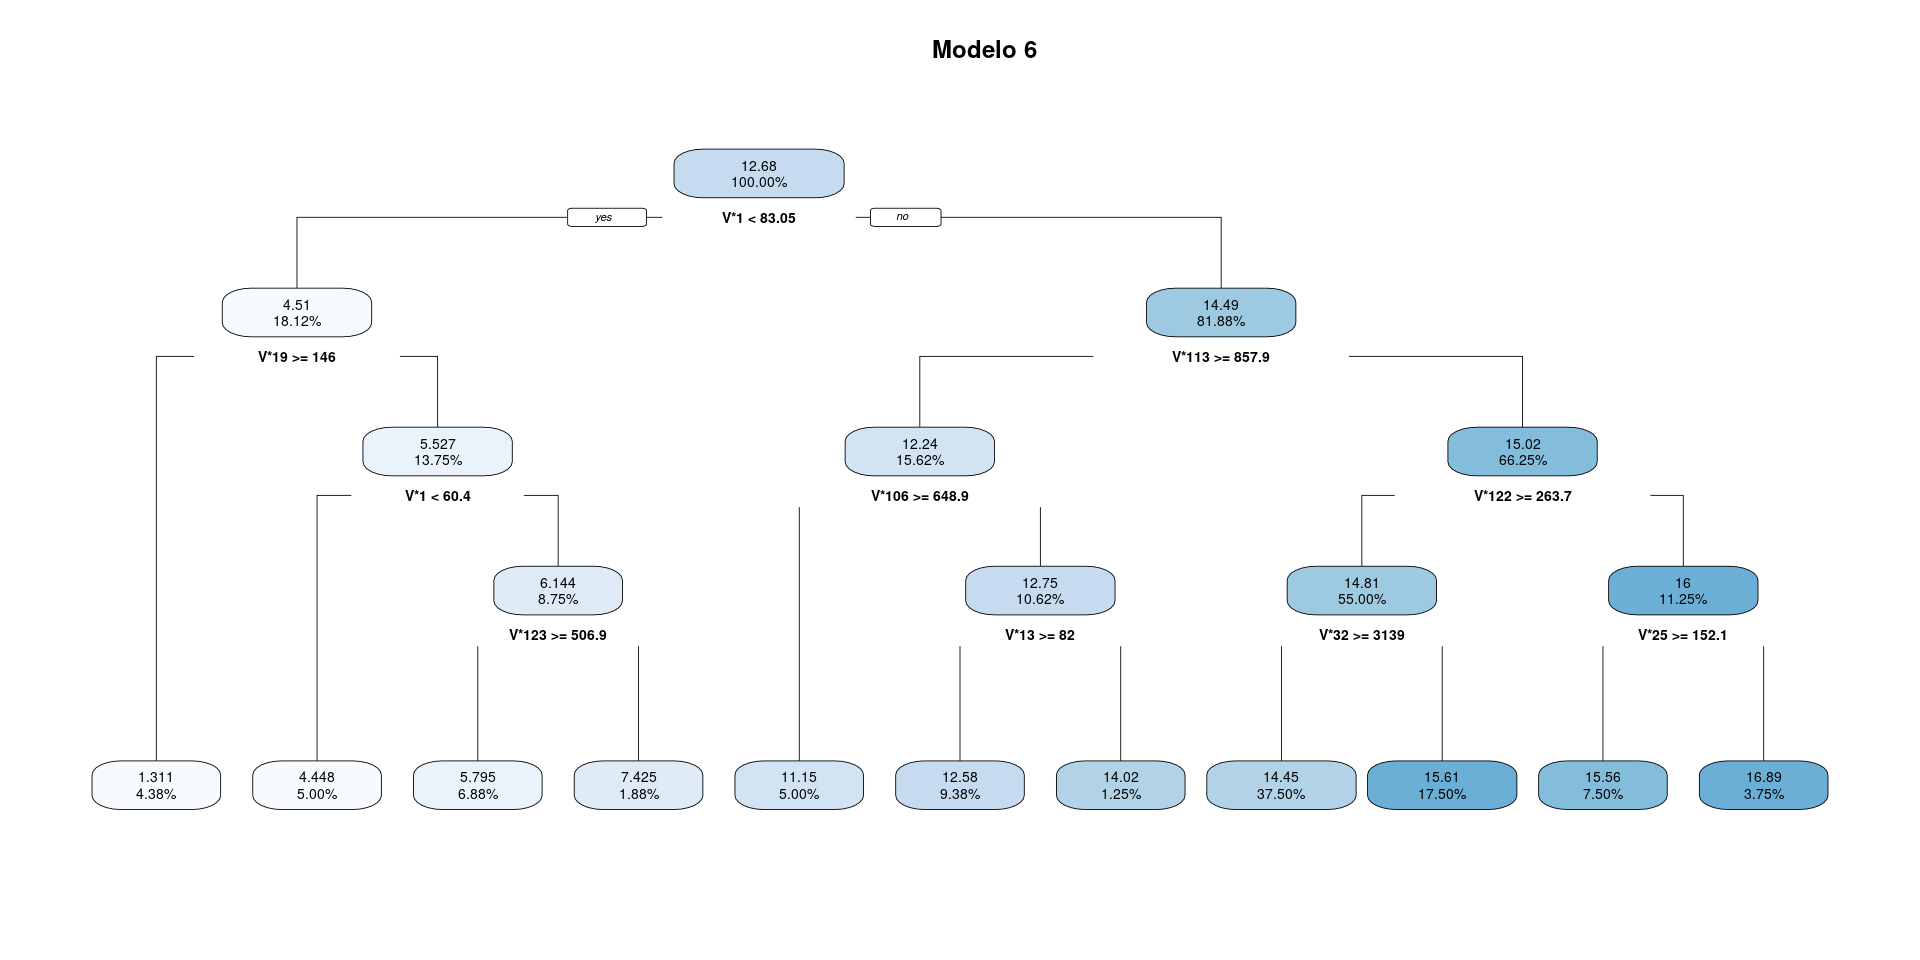

In [33]:
rpart.plot(modelo2, digits=4)
title("Modelo 6")

In [34]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- preprocesamiento_agrupar(TRAIN_X, mejores_parametros$Ventana)
err = 0
for(i in indices){
    train_df <- X[-i,]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- rpart(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.46312880091269"


In [35]:
p = 18
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.9061908

# Modelo 3: KNN para regresión

In [4]:
library(caret)

Loading required package: lattice

Loading required package: ggplot2



In [36]:
library(reticulate)

In [37]:
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

In [38]:
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

In [40]:
setSeed()

n = nrow(TRAIN_X)
k = 10

resultados <- data.frame(
    Ventana  =integer(), 
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    S        =integer(),
    Error    =double()
)


indices = obtener_indices_kfold(n, k)

ventanas <- seq(1, 32, 1)
Ks <- 1:10
ws <- c(1, 2)
ps <- c(1, 2)

escaladores <- c(StScaler(), MMScaler())
for(ventana in ventanas){
    X <- preprocesamiento_agrupar(TRAIN_X, ventana)
    for(K in Ks){
        for(w in ws){
            wei = ifelse(w==1, "uniform", "distance")
            for(p in ps){
                for(s in 1:length(escaladores)){
                    escalador = escaladores[[s]]
                    err = 0
                    for(i in indices){
                        X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                        Y_train = TRAIN_Y[-i]

                        X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                        Y_test = TRAIN_Y[i]

                        model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)
                        Y_pred = as.double(model$predict(X_test_scaled))
                        err = err + sum((Y_test - Y_pred)^2)
                    }
                    resultados = rbind(resultados, list(ventana, K, w, p, s, err/n))
                }
            }
        }
    }
    message(progreso(ventana, ventanas))
}
colnames(resultados)  <- c("Ventana", "K", "Weights", "Distance", "S", "Error")

El progreso es del 3.1 %

El progreso es del 6.2 %

El progreso es del 9.4 %

El progreso es del 12.5 %

El progreso es del 15.6 %

El progreso es del 18.8 %

El progreso es del 21.9 %

El progreso es del 25 %

El progreso es del 28.1 %

El progreso es del 31.2 %

El progreso es del 34.4 %

El progreso es del 37.5 %

El progreso es del 40.6 %

El progreso es del 43.8 %

El progreso es del 46.9 %

El progreso es del 50 %

El progreso es del 53.1 %

El progreso es del 56.2 %

El progreso es del 59.4 %

El progreso es del 62.5 %

El progreso es del 65.6 %

El progreso es del 68.8 %

El progreso es del 71.9 %

El progreso es del 75 %

El progreso es del 78.1 %

El progreso es del 81.2 %

El progreso es del 84.4 %

El progreso es del 87.5 %

El progreso es del 90.6 %

El progreso es del 93.8 %

El progreso es del 96.9 %

El progreso es del 100 %



In [42]:
mean(resultados$Error)

[1] 1.044455

In [57]:
print(min(resultados$Error))
print(which.min(resultados$Error))

mejores_parametros <- resultados[which.min(resultados$Error), ]
mejores_parametros

[1] 0.6775493
[1] 174


,Ventana,K,Weights,Distance,S,Error
,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>
174,32,2,2,1,2,0.6775493


Cálculo del error

In [ ]:
escalador = escaladores[[mejores_parametros$Escalador]]
X_scaled <- escalador$fit_transform(TRAIN_X)

wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
modelo3 <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_scaled, TRAIN_Y)

In [59]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- preprocesamiento_agrupar(TRAIN_X, mejores_parametros$Ventana)
escalador = escaladores[[mejores_parametros$S]]
wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, Y_train)
    Y_pred = as.double(model$predict(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.596550188566475"


# Modelo 4: regresión no paramétrica

In [60]:
D <- function(x, y) (sum((abs(x-y))))
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}

In [64]:
setSeed()

n = nrow(TRAIN_X)
k = 10

indices = obtener_indices_kfold(n, k)

resultados <- data.frame(
    Ventana =integer(),
    h       =double(),
    K       =integer(),
    Error   =double()
)
escalador = MMScaler()

hs = seq(0.1, 15, l=30)
Ks = list((function(x) (0.5 * (abs(x)<1))),
          (function(x) (dnorm(x))),
          (function(x) (0.75*(1-x^2)*(abs(x)<1))),
          (function(x) ((15/16)*((1-x^2)^2)*(abs(x)<1)))
       )
ventanas <- seq(2, 32, 2)
for(ventana in ventanas){
    X <- preprocesamiento_agrupar(TRAIN_X, ventana)
    for(h in hs){
        for(Knumber in 1:length(Ks)){
            K = Ks[[Knumber]]
            err = 0
            for(i in indices){
                X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                Y_train = TRAIN_Y[-i]

                X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                Y_test = TRAIN_Y[i]

                Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
                err = err + sum((Y_test - Y_pred)^2)
            }
            resultados = rbind(resultados, list(ventana, h, Knumber, err/n))
        }
    }
    message(progreso(ventana, ventanas))
}
colnames(resultados)  <- c("Ventana", "h", "K", "Error")

El progreso es del 6.2 %

El progreso es del 12.5 %

El progreso es del 18.8 %

El progreso es del 25 %

El progreso es del 31.2 %

El progreso es del 37.5 %

El progreso es del 43.8 %

El progreso es del 50 %

El progreso es del 56.2 %

El progreso es del 62.5 %

El progreso es del 68.8 %

El progreso es del 75 %

El progreso es del 81.2 %

El progreso es del 87.5 %

El progreso es del 93.8 %

El progreso es del 100 %



In [67]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,Ventana,h,K,Error
,<dbl>,<dbl>,<int>,<dbl>
134,4,1.641379,2,0.7181253


Cálculo del error

In [70]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- preprocesamiento_agrupar(TRAIN_X, mejores_parametros$Ventana)
escalador = MMScaler()
K = Ks[[mejores_parametros$K]]
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, mejores_parametros$h, K)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.679610398378588"
